# XGBoost models with SHAP

## Below is the binary classification xgboost model, multi-class classification xgboost model, and the attack-only multi-class classification xgboost models all explained with shap.

## Install the proper libraries:
### I added installs for the libraries I used. It is important to have these exact versions of numpy and shap or it won't work

In [1]:
!pip install xgboost pandas
!pip install numpy==1.26.4 shap==0.42.1 --force-reinstall

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
  Using cached shap-0.42.1-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl (547 kB)
  Using cached slicer-0.0.7-py3-none-any.whl (14 kB)
  Using cached packaging-25.0-py3-none-any.whl (66 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
  Using cached pandas-2.3.3-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.8 MB)
  Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.7 MB)
  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
  Using cached numba-0.63.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.7 MB

    Uninstalling scikit-learn-1.7.2:
      Successfully uninstalled scikit-learn-1.7.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.3.3
    Uninstalling pandas-2.3.3:
      Successfully uninstalled pandas-2.3.3
  Attempting uninstall: shap
    Found existing installation: shap 0.42.1
    Uninstalling shap-0.42.1:
      Successfully uninstalled shap-0.42.1


## Import the libraries:
### I then imported the libraries I just installed. I used xgboost the add in the models, Shap to explain them, pandas to use DataFrames, numpy to use their math functions, and pyplot to help build the visualizations.

In [2]:
import xgboost as xgb
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

/home/tbeaugh/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/tbeaugh/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


## Load in the datasets:
### I imported in the datasets so I could do some basic data analysis.

In [3]:
binarydf = pd.read_csv("../../notebooks/Tatum/binary_data.csv")
multiclassdf = pd.read_csv("../../notebooks/Tatum/multi_class_data.csv")
attackonlydf = pd.read_csv("../../notebooks/Tatum/attack_only_data.csv")

## Binary Classification Data:
### The data used in binary classification has 352205 entries and 62 columns

In [4]:
binarydf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352205 entries, 0 to 352204
Data columns (total 62 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Unnamed: 0                 352205 non-null  int64  
 1   bucket                     352205 non-null  object 
 2   system_id                  352205 non-null  object 
 3   protocol                   352205 non-null  object 
 4   avg_size                   352205 non-null  float64
 5   source_total_packets       352205 non-null  int64  
 6   destination_total_packets  352205 non-null  int64  
 7   min_size                   352205 non-null  int64  
 8   max_size                   352205 non-null  int64  
 9   num_connections            352205 non-null  int64  
 10  source_ip                  351910 non-null  object 
 11  source_port                351841 non-null  float64
 12  source_mac                 352205 non-null  object 
 13  destination_ip             35

### The percent of attack rows in data

In [5]:
print(f"Binary classification data: {(binarydf['num_attacks']>0).mean()*100:.2f}% rows are attacks")

Binary classification data: 54.16% rows are attacks


## Multi-class Classification Data:
### The data used in multi-class classification is 352118 entries and 58 columns.

In [6]:
multiclassdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352118 entries, 0 to 352117
Data columns (total 58 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Unnamed: 0                 352118 non-null  int64  
 1   bucket                     352118 non-null  object 
 2   system_id                  352118 non-null  object 
 3   protocol                   352118 non-null  object 
 4   avg_size                   352118 non-null  float64
 5   source_total_packets       352118 non-null  int64  
 6   destination_total_packets  352118 non-null  int64  
 7   min_size                   352118 non-null  int64  
 8   max_size                   352118 non-null  int64  
 9   num_connections            352118 non-null  int64  
 10  source_ip                  351909 non-null  object 
 11  source_port                351841 non-null  float64
 12  source_mac                 352118 non-null  object 
 13  destination_ip             35

### Find the percent attack rows in data

In [7]:
print(f"Multi-class data: {(multiclassdf['num_attacks']>0).mean()*100:.2f}% rows are attacks")

Multi-class data: 54.15% rows are attacks


## Attack-only Classification Data:
### the data used in the attack-only multi-class classification model has 190656 entries and 62 columns

In [8]:
attackonlydf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190656 entries, 0 to 190655
Data columns (total 62 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Unnamed: 0                 190656 non-null  int64  
 1   bucket                     190656 non-null  object 
 2   system_id                  190656 non-null  object 
 3   protocol                   190656 non-null  object 
 4   avg_size                   190656 non-null  float64
 5   source_total_packets       190656 non-null  int64  
 6   destination_total_packets  190656 non-null  int64  
 7   min_size                   190656 non-null  int64  
 8   max_size                   190656 non-null  int64  
 9   num_connections            190656 non-null  int64  
 10  source_ip                  190447 non-null  object 
 11  source_port                190379 non-null  float64
 12  source_mac                 190656 non-null  object 
 13  destination_ip             19

### Found the number of attack rows in data

In [9]:
print(f"Attack only data: {(attackonlydf['num_attacks']>0).mean()*100:.2f}% rows are attacks")

Attack only data: 100.00% rows are attacks


## Load in the models:
### I saved the models and loaded them here. All three models are XGBoost classification models.

In [10]:
binaryClassModel = xgb.XGBClassifier()
binaryClassModel.load_model("binary_class_xgb_model.json")

multiclassModel = xgb.XGBClassifier()
multiclassModel.load_model("multiclass_xgb.json")

attackonlyModel = xgb.XGBClassifier()
attackonlyModel.load_model("attack_only_xgb_model.json")

## Load in the features
### I saved the features lists as well and loaded them here. I also printed the features involved in training the models for reference

### 1. Binary classification

In [11]:
binaryX = pd.read_csv("binary_X_features.csv")
print(binaryX.columns.tolist())

['protocol', 'avg_size', 'source_total_packets', 'destination_total_packets', 'min_size', 'max_size', 'num_connections', 'source_port', 'destination_port', 'source_asset', 'destination_asset', 'tcp_cwr_count', 'tcp_ece_count', 'tcp_urg_count', 'tcp_ack_count', 'tcp_psh_count', 'tcp_rst_count', 'tcp_syn_count', 'tcp_fin_count', 'tcp_syn_ratio', 'tcp_ack_ratio', 'modbus_response_count', 'modbus_response_ratio', 'avg_modbus_response_code', 'modbus_response_present', 'mac_src', 'mac_dst', 'macport_src', 'macport_dst', 'min_value', 'max_value', 'avg_value', 'num_measurements', 'mac_nodes_1m', 'mac_edges_1m', 'mac_avg_degree_1m', 'mac_density_1m', 'mac_nodes_5m', 'mac_edges_5m', 'mac_avg_degree_5m', 'mac_density_5m', 'mp_nodes_1m', 'mp_edges_1m', 'mp_avg_degree_1m', 'mp_density_1m', 'mp_nodes_5m', 'mp_edges_5m', 'mp_avg_degree_5m', 'mp_density_5m']


### 2. Multi-class Classification

In [12]:
multiclassX = pd.read_csv("multiclass_X_features.csv")
print(multiclassX.columns.tolist())

['protocol', 'avg_size', 'source_total_packets', 'destination_total_packets', 'min_size', 'max_size', 'num_connections', 'source_port', 'destination_port', 'source_asset', 'destination_asset', 'tcp_cwr_count', 'tcp_ece_count', 'tcp_urg_count', 'tcp_ack_count', 'tcp_psh_count', 'tcp_rst_count', 'tcp_syn_count', 'tcp_fin_count', 'tcp_syn_ratio', 'tcp_ack_ratio', 'modbus_response_count', 'modbus_response_ratio', 'avg_modbus_response_code', 'modbus_response_present', 'min_value', 'max_value', 'avg_value', 'num_measurements', 'mac_nodes_1m', 'mac_edges_1m', 'mac_avg_degree_1m', 'mac_density_1m', 'mac_nodes_5m', 'mac_edges_5m', 'mac_avg_degree_5m', 'mac_density_5m', 'mp_nodes_1m', 'mp_edges_1m', 'mp_avg_degree_1m', 'mp_density_1m', 'mp_nodes_5m', 'mp_edges_5m', 'mp_avg_degree_5m', 'mp_density_5m']


### 3. Attack-only Classification

In [13]:
attackonlyX = pd.read_csv("attack_only_X_features.csv")
print(attackonlyX.columns.tolist())

['protocol', 'avg_size', 'source_total_packets', 'destination_total_packets', 'min_size', 'max_size', 'num_connections', 'source_port', 'destination_port', 'source_asset', 'destination_asset', 'tcp_cwr_count', 'tcp_ece_count', 'tcp_urg_count', 'tcp_ack_count', 'tcp_psh_count', 'tcp_rst_count', 'tcp_syn_count', 'tcp_fin_count', 'tcp_syn_ratio', 'tcp_ack_ratio', 'modbus_response_count', 'modbus_response_ratio', 'avg_modbus_response_code', 'modbus_response_present', 'mac_src', 'mac_dst', 'macport_src', 'macport_dst', 'min_value', 'max_value', 'avg_value', 'num_measurements', 'mac_nodes_1m', 'mac_edges_1m', 'mac_avg_degree_1m', 'mac_density_1m', 'mac_nodes_5m', 'mac_edges_5m', 'mac_avg_degree_5m', 'mac_density_5m', 'mp_nodes_1m', 'mp_edges_1m', 'mp_avg_degree_1m', 'mp_density_1m', 'mp_nodes_5m', 'mp_edges_5m', 'mp_avg_degree_5m', 'mp_density_5m']


## Defined and assigned shap explainer for multi class classification model:
### There was two different explainers that could've worked for explaining xgboost classification models: tree explainer and kernal explainer.  I decided to go with the tree explainer because it is computationally cheaper and is built specifically for tree-based models. I defined and initialized the explainer by plugging in the multi clssification model. I then created shap_values which is a list of 2d arrays and assigned it the shap values for the model. (ex: shap_values[0][1][3] would represent class 0, data sample 1, and feature 3) 

In [14]:
explainer = shap.TreeExplainer(multiclassModel)
shap_values = explainer.shap_values(multiclassX)

## Get shapley values
### SHAP calculates the contribution of each feature to the predictions made by the model. Positive SHAP values push the prediction higher and negative SHAP values push the predictions lower. 
### To get the global importance we first get the absolute value of each shap value. Then we get the mean across all samples for each feature. This gives us an array representing average impact. Finally, we take the mean across all the classes. We are left with an array of length of the number of features representing the global importance accross all classes.

In [15]:
shap_importance = np.mean(
    [np.abs(sv).mean(axis=0) for sv in shap_values],
    axis=0
)


## Build dataframe to hold feature importance
### I then created a data frame to hold the features and their importances. I then headed it to print the top 10 most important features.

In [16]:
# Build DataFrame
feat_importance_df = pd.DataFrame({
    "feature": multiclassX.columns,
    "importance": shap_importance
}).sort_values("importance", ascending=False)

print(feat_importance_df.head(10))

                      feature  importance
30               mac_edges_1m    0.744443
39           mp_avg_degree_1m    0.591707
19              tcp_syn_ratio    0.583535
37                mp_nodes_1m    0.460227
32             mac_density_1m    0.366165
43           mp_avg_degree_5m    0.301798
27                  avg_value    0.271067
20              tcp_ack_ratio    0.266636
3   destination_total_packets    0.253082
2        source_total_packets    0.250695


## Create summary plot:
### I created a summary plot showing the impact of each feature. The x-axis represents the impact of a feature on the model's output. Features are ranked by average importance. For the multi class classifiation model, mac_edges_1m is the most important feature and MITM is the class it impacts most. Class 0 is DoS, class 1 is MITM, class 2 is Normal, class 3 is Physical Fault, and class 4 is Scan.

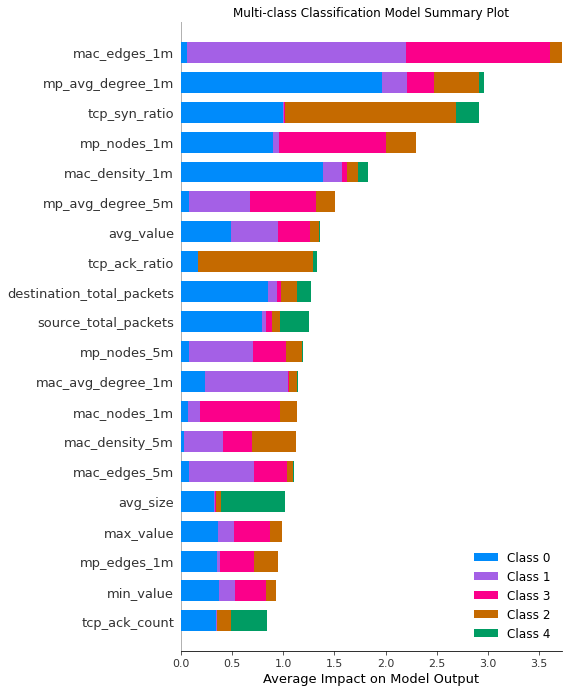

In [17]:
shap.summary_plot(shap_values, multiclassX, plot_type= 'bar', show=False)

plt.xlabel("Average Impact on Model Output")
plt.title("Multi-class Classification Model Summary Plot")
plt.show()

## Create shap explainer for attack-only model
### I used the same strategy for the attack-only multi-class classification model as I used for the combined data.

In [18]:
explainer = shap.TreeExplainer(attackonlyModel)
shap_values = explainer.shap_values(attackonlyX)

shap_importance = np.mean(
    [np.abs(sv).mean(axis=0) for sv in shap_values],
    axis=0
)

feat_importance_df = pd.DataFrame({
    "feature": attackonlyX.columns,
    "importance": shap_importance
}).sort_values("importance", ascending=False)

print(feat_importance_df.head(10))

              feature  importance
31          avg_value    0.584156
33       mac_nodes_1m    0.474185
43   mp_avg_degree_1m    0.445404
41        mp_nodes_1m    0.265926
34       mac_edges_1m    0.245806
47   mp_avg_degree_5m    0.232328
29          min_value    0.207539
38       mac_edges_5m    0.130174
35  mac_avg_degree_1m    0.128953
45        mp_nodes_5m    0.117864


### Plot summary of attack only explainer

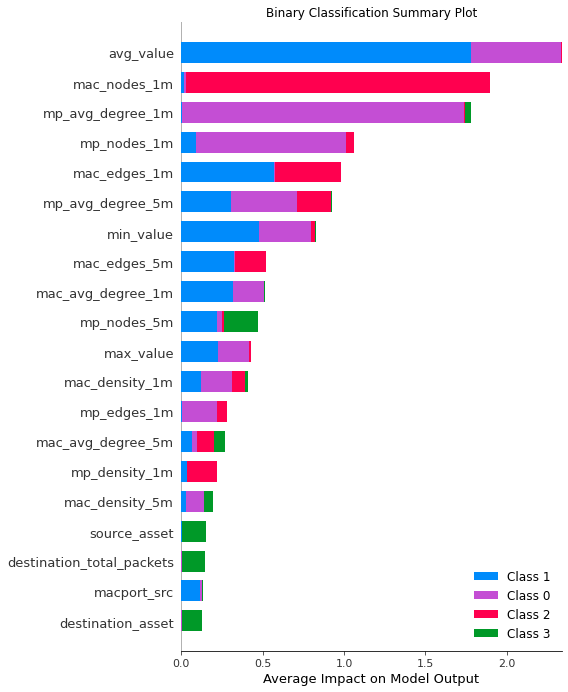

In [19]:
shap.summary_plot(shap_values, attackonlyX, plot_type= 'bar', show=False)

plt.xlabel("Average Impact on Model Output")
plt.title("Binary Classification Summary Plot")
plt.show()

## Create shap explainer for binary classification model
### I used the same strategy for binary classification except I removed the outermost mean calculationg because you dont have to calculate the average for each class considering there are only two classes.

In [20]:
explainer = shap.TreeExplainer(binaryClassModel)
shap_values = explainer.shap_values(binaryX)

shap_importance = np.abs(shap_values).mean(axis=0)

feat_importance_df = pd.DataFrame({
    "feature": binaryX.columns,
    "importance": shap_importance
}).sort_values("importance", ascending=False)

print(feat_importance_df.head(10))

             feature  importance
19     tcp_syn_ratio    1.207998
25           mac_src    1.190142
44     mp_density_1m    0.710189
43  mp_avg_degree_1m    0.684210
27       macport_src    0.663508
41       mp_nodes_1m    0.644702
40    mac_density_5m    0.530943
20     tcp_ack_ratio    0.524512
47  mp_avg_degree_5m    0.397418
48     mp_density_5m    0.375063


## Print summary graph for binary classification explainer
### The bar graph for binary classification is only one color because there is only one decision boundary.

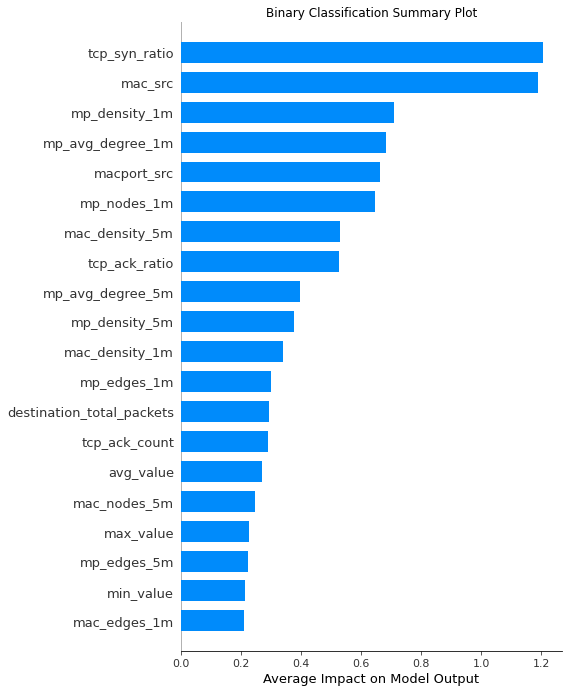

In [21]:
shap.summary_plot(shap_values, binaryX, plot_type='bar', show=False)

plt.xlabel("Average Impact on Model Output")
plt.title("Binary Classification Summary Plot")
plt.show()